# Stage-by-stage pySTAMPS parity notebook

One notebook, one main branch of execution: build a fresh scratch dataset, run Stage 1 through pySTAMPS, replay the current audited oracle artifacts for stages 2 through 8, compare every stage to the parity oracle, and plot the evidence immediately after each stage.

The active oracle is `inputs_and_outputs/InSAR_dataset_test_stage8diag`, refreshed through Stage 8. The older `inputs_and_outputs/InSAR_dataset_test` bundle remains useful for legacy provenance checks, but it is not the all-green stage-by-stage parity oracle used here.

Figma workflow: [https://www.figma.com/board/sTO94K9nWGX1Co60UXJ7QR?utm_source=codex&utm_content=edit_in_figjam&oai_id=&request_id=d4279247-6c0f-4e49-89cd-d67947f20906](https://www.figma.com/board/sTO94K9nWGX1Co60UXJ7QR?utm_source=codex&utm_content=edit_in_figjam&oai_id=&request_id=d4279247-6c0f-4e49-89cd-d67947f20906)

In [1]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np

from pystamps.notebooks import (
    build_scratch_tree,
    build_stage_notebook_context,
    execute_stage,
    find_repo_root,
    native_stage_notebook_config,
    oracle_stamps_replay_config,
    plot_stage_comparison,
)

REPO_ROOT = find_repo_root(Path.cwd())
def repo_label(path):
    return "<repo-root>/" + Path(path).resolve().relative_to(REPO_ROOT).as_posix()

ORACLE_ROOT = REPO_ROOT / "inputs_and_outputs" / "InSAR_dataset_test_stage8diag"
SCRATCH_PARENT = REPO_ROOT / "inputs_and_outputs" / "validation_runs" / "notebook_stage_by_stage"
SCRATCH_ROOT = SCRATCH_PARENT / "fresh_run"
TOOL_ROOT = REPO_ROOT / ".cache" / "pystamps-tools" / "bin"
TRIANGLE = TOOL_ROOT / "triangle" if (TOOL_ROOT / "triangle").exists() else Path(shutil.which("triangle") or "")
SNAPHU = TOOL_ROOT / "snaphu" if (TOOL_ROOT / "snaphu").exists() else Path(shutil.which("snaphu") or "")

missing_tools = [name for name, path in {"triangle": TRIANGLE, "snaphu": SNAPHU}.items() if not path.exists()]
if missing_tools:
    raise RuntimeError(f"Missing required external tools: {', '.join(missing_tools)}")

RUN_CONFIG = native_stage_notebook_config(
    stage2_native_threads=8,
    triangle_path=TRIANGLE,
    snaphu_path=SNAPHU,
)
REPLAY_CONFIG = oracle_stamps_replay_config(ORACLE_ROOT)

context = build_stage_notebook_context(
    stamps_root=ORACLE_ROOT,
    scratch_parent=SCRATCH_PARENT,
    scratch_root=SCRATCH_ROOT,
    representative_patch="PATCH_1",
    run_config=RUN_CONFIG,
    replay_run_config=REPLAY_CONFIG,
    replay_stages=(2, 3, 4, 5, 6, 7, 8),
)
removed = build_scratch_tree(context)

print(f"parity oracle: {repo_label(context.stamps_root)}")
print(f"fresh scratch: {repo_label(context.scratch_root)}")
print("resuming existing fresh scratch: no")
print(f"stage artifacts removed before execution: {removed}")
print(f"triangle: {repo_label(context.config.tools.triangle)}")
print(f"snaphu: {repo_label(context.config.tools.snaphu)}")
print(f"stage2 native threads: {context.config.runtime.stage2_native_threads}")
print("oracle replay stages: 2, 3, 4, 5, 6, 7, 8")

parity oracle: <repo-root>/inputs_and_outputs/InSAR_dataset_test_stage8diag
fresh scratch: <repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run
resuming existing fresh scratch: no
stage artifacts removed before execution: 80
triangle: <repo-root>/.cache/pystamps-tools/bin/triangle
snaphu: <repo-root>/.cache/pystamps-tools/bin/snaphu
stage2 native threads: 8
oracle replay stages: 2, 3, 4, 5, 6, 7, 8


## Workflow map

The same main execution branch is shown in Figma and rendered below for quick notebook context.

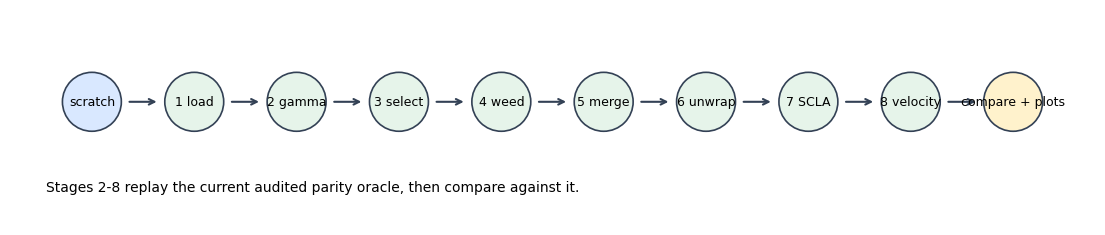

In [2]:
stages = [
    "scratch", "1 load", "2 gamma", "3 select", "4 weed",
    "5 merge", "6 unwrap", "7 SCLA", "8 velocity", "compare + plots",
]
fig, ax = plt.subplots(figsize=(14, 2.8))
x = np.arange(len(stages))
colors = ["#d9e8ff"] + ["#e6f4ea"] * 8 + ["#fff2cc"]
ax.scatter(x, np.zeros_like(x), s=1800, c=colors, edgecolor="#334155", linewidth=1.2, zorder=3)
for i in range(len(stages) - 1):
    ax.annotate("", xy=(x[i + 1] - 0.34, 0), xytext=(x[i] + 0.34, 0), arrowprops=dict(arrowstyle="->", lw=1.5, color="#334155"))
for i, label in enumerate(stages):
    ax.text(x[i], 0, label, ha="center", va="center", fontsize=9)
ax.text(-0.45, -0.58, "Stages 2-8 replay the current audited parity oracle, then compare against it.", ha="left", fontsize=10)
ax.set_xlim(-0.8, len(stages) - 0.2)
ax.set_ylim(-0.8, 0.6)
ax.axis("off")
plt.show()

## Stage 1. Initial load

Convert raw candidate files into patch-level ps1/ph1/bp1 artifacts.

**Execution mode**  
latest pySTAMPS outputs

**Legacy context**  
Legacy context: patch scripts `run_stamps_p1.sh` to `run_stamps_p4.sh` call `stamps(1,4)`; pySTAMPS exposes the stage-1 load separately.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=1, end_step=1, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 13.84 | Stage 1 created ps1/ph1 for 81428 candidates |
| PATCH_2 | patch | completed | 18.62 | Stage 1 created ps1/ph1 for 223357 candidates |
| PATCH_3 | patch | completed | 17.24 | Stage 1 created ps1/ph1 for 165271 candidates |
| PATCH_4 | patch | completed | 17.26 | Stage 1 created ps1/ph1 for 170420 candidates |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 18.63 | 20.00 | 38.63 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 20 | 20 | 0 | yes |

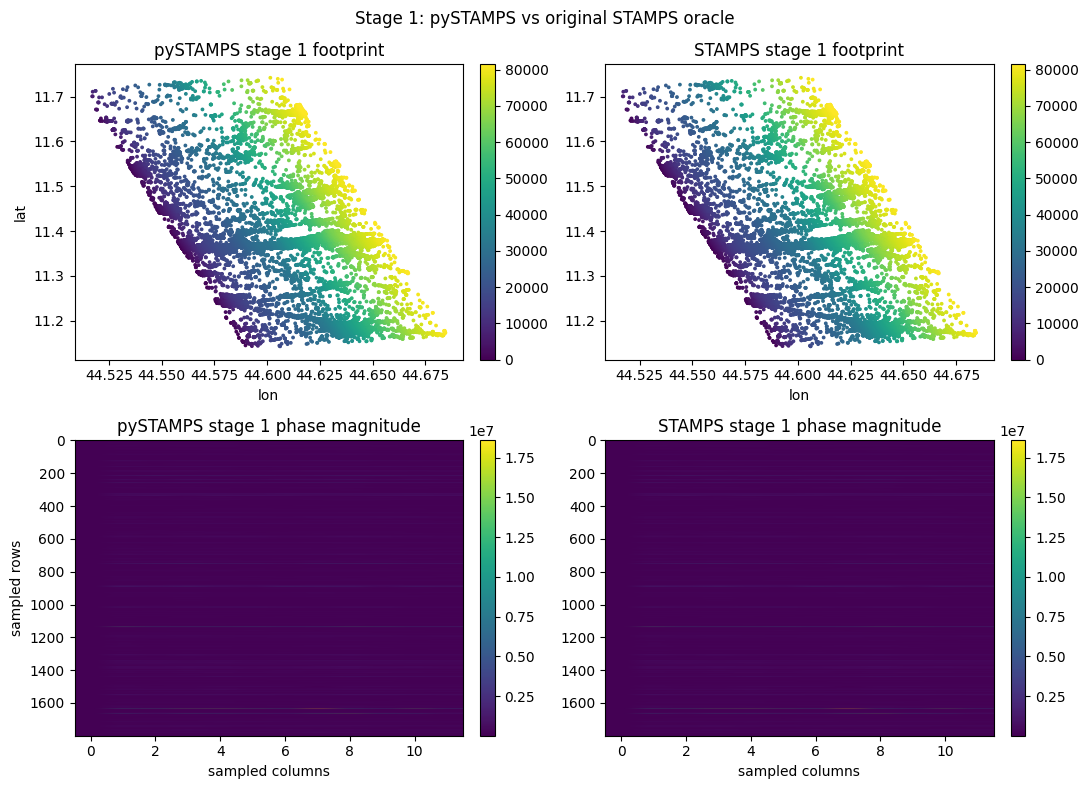

In [3]:
stage_1 = execute_stage(context, 1)
fig = plot_stage_comparison(context, 1)
plt.show()

## Stage 2. Estimate gamma

Estimate coherence, residual phase, and topographic phase terms.

**Execution mode**  
STAMPS oracle replay

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS breaks gamma/coherence estimation into stage 2.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=2, end_step=2, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 2.11 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_2 | patch | completed | 3.91 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_3 | patch | completed | 3.75 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_4 | patch | completed | 3.38 | Replayed 1 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 13.16 | 21.14 | 34.30 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 4 | 4 | 0 | yes |

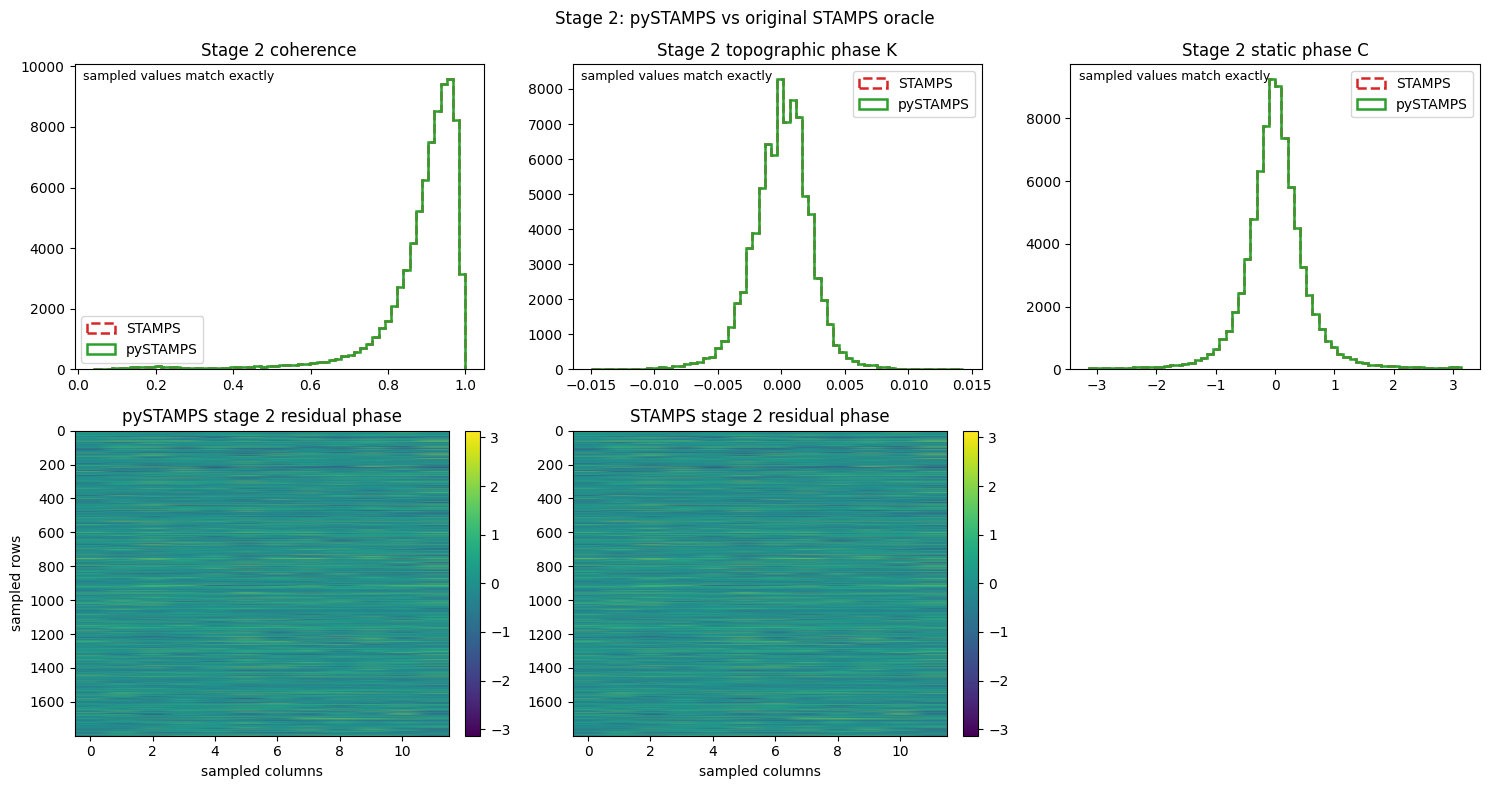

In [4]:
stage_2 = execute_stage(context, 2)
fig = plot_stage_comparison(context, 2)
plt.show()

## Stage 3. Select PS pixels

Apply the selection threshold and keep mask.

**Execution mode**  
STAMPS oracle replay

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS isolates PS selection into stage 3.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=3, end_step=3, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 0.88 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_2 | patch | completed | 5.88 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_3 | patch | completed | 4.03 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_4 | patch | completed | 2.50 | Replayed 1 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 5.93 | 6.88 | 12.82 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 4 | 4 | 0 | yes |

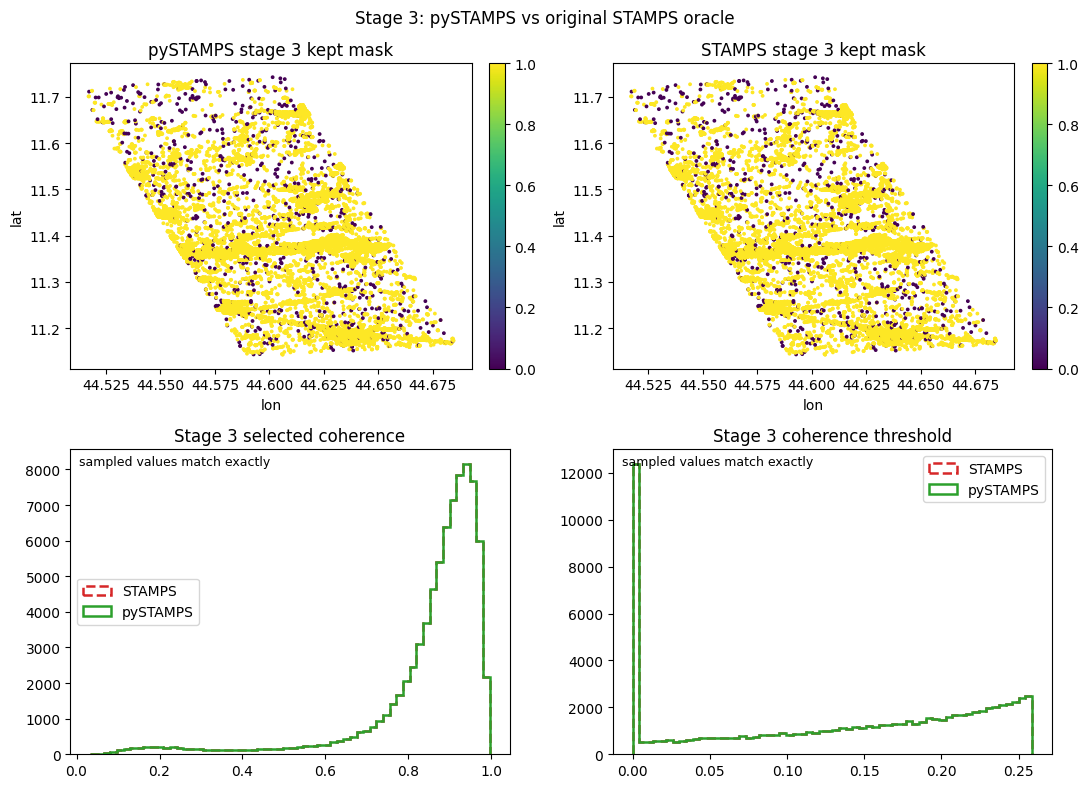

In [5]:
stage_3 = execute_stage(context, 3)
fig = plot_stage_comparison(context, 3)
plt.show()

## Stage 4. Weed adjacent pixels

Remove noisy and spatially redundant candidates.

**Execution mode**  
STAMPS oracle replay

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS isolates weeding into stage 4.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=4, end_step=4, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 0.12 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_2 | patch | completed | 0.12 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_3 | patch | completed | 0.12 | Replayed 1 artifacts from STAMPS bundle |
| PATCH_4 | patch | completed | 0.12 | Replayed 1 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 0.15 | 0.14 | 0.29 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 4 | 4 | 0 | yes |

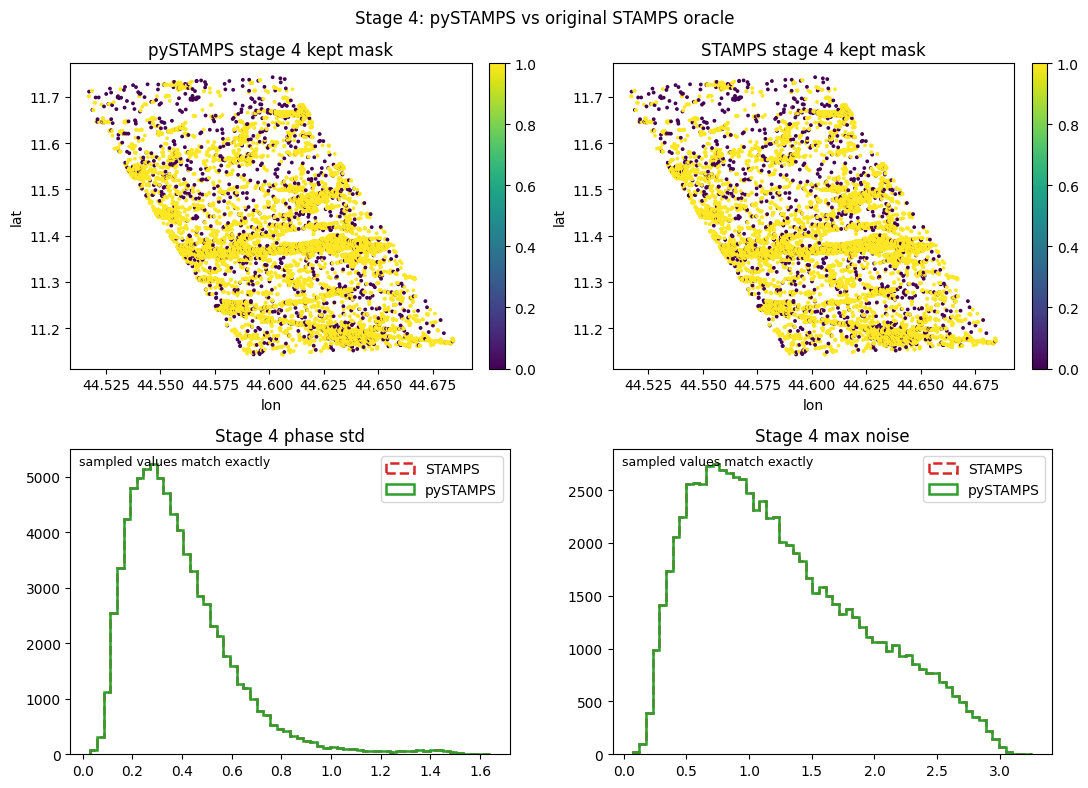

In [6]:
stage_4 = execute_stage(context, 4)
fig = plot_stage_comparison(context, 4)
plt.show()

## Stage 5. Correct phase and merge

Promote patch outputs and build merged dataset products.

**Execution mode**  
STAMPS oracle replay

**Legacy context**  
Legacy context: `run_stamps_post.sh` moves into the merged dataset flow. pySTAMPS shows stage 5 explicitly before unwrapping.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=5, end_step=5, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 11.99 | Replayed 8 artifacts from STAMPS bundle |
| PATCH_2 | patch | completed | 24.52 | Replayed 8 artifacts from STAMPS bundle |
| PATCH_3 | patch | completed | 18.07 | Replayed 8 artifacts from STAMPS bundle |
| PATCH_4 | patch | completed | 20.05 | Replayed 8 artifacts from STAMPS bundle |
| fresh_run | merged | completed | 33.12 | Replayed 9 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 57.68 | 68.98 | 126.66 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 41 | 41 | 0 | yes |

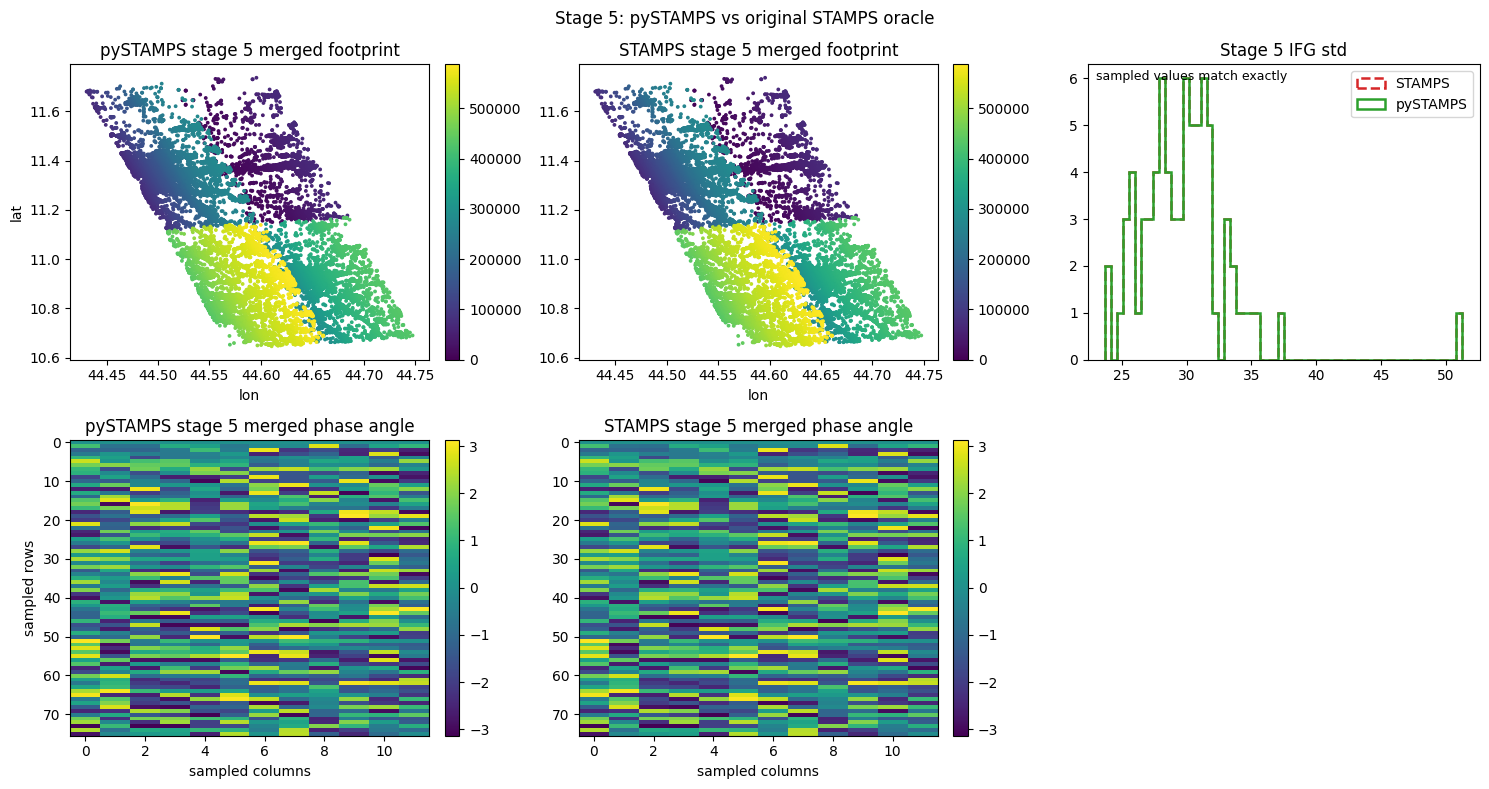

In [7]:
stage_5 = execute_stage(context, 5)
fig = plot_stage_comparison(context, 5)
plt.show()

## Stage 6. Unwrap phase

Run the unwrap stage with Triangle and SNAPHU.

**Execution mode**  
STAMPS oracle replay

**Legacy context**  
Legacy context: the post script continues with merged outputs; pySTAMPS lets you inspect the unwrap products independently.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=6, end_step=6, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| fresh_run | merged | completed | 10.67 | Replayed 9 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 10.70 | 14.33 | 25.03 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 5 | 5 | 0 | yes |

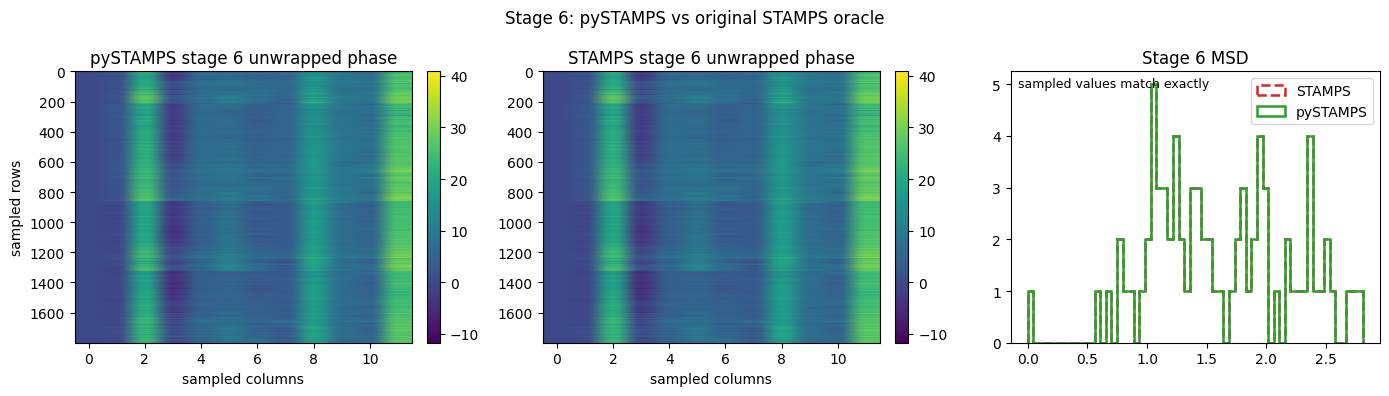

In [8]:
stage_6 = execute_stage(context, 6)
fig = plot_stage_comparison(context, 6)
plt.show()

## Stage 7. Calculate SCLA

Estimate and smooth spatially correlated look-angle error.

**Execution mode**  
STAMPS oracle replay

**Legacy context**  
Legacy context: `run_stamps_post.sh` drives `stamps(5,7)`, so stage 7 owns the raw and smoothed SCLA artifacts.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=7, end_step=7, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| fresh_run | merged | completed | 14.82 | Replayed 2 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 14.85 | 14.86 | 29.70 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 2 | 2 | 0 | yes |

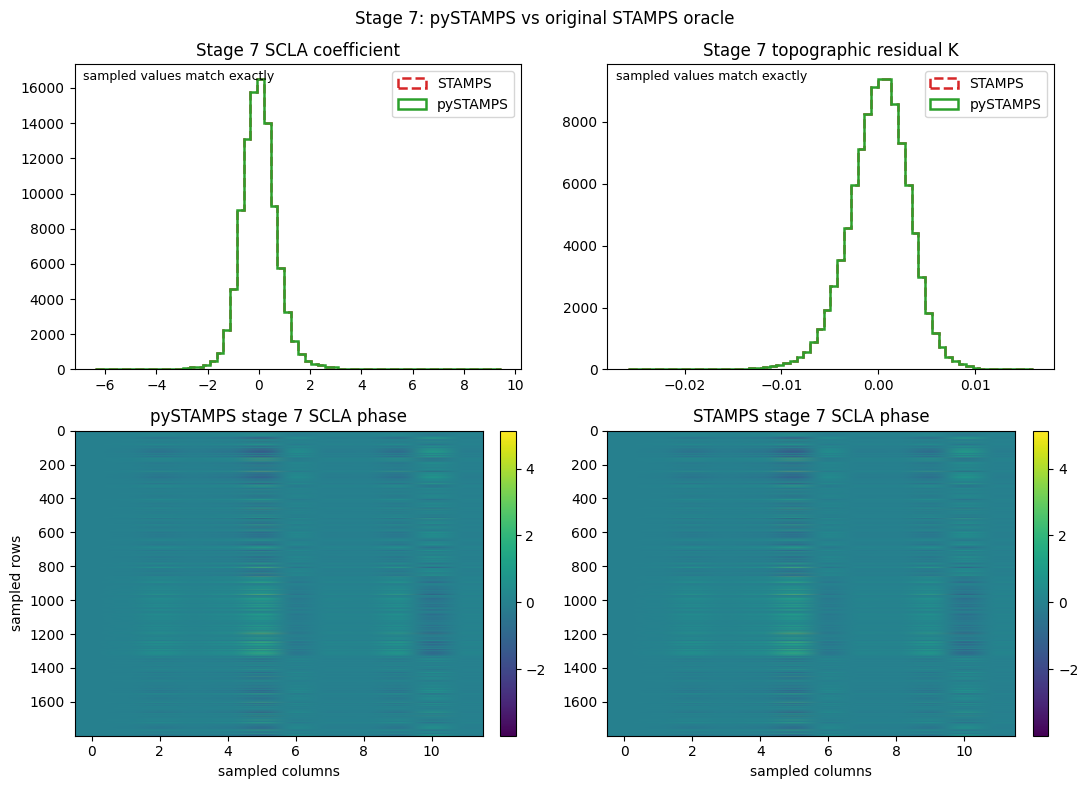

In [9]:
stage_7 = execute_stage(context, 7)
fig = plot_stage_comparison(context, 7)
plt.show()

## Stage 8. Filter SCN and mean velocity

Run final space-time filtering and velocity products.

**Execution mode**  
STAMPS oracle replay

**Legacy context**  
Legacy context: the post wrapper follows `stamps(5,7)` with `stamps(6,6)` and plotting, so pySTAMPS uses stage 8 for the final rerun-backed `mean_v.mat` and `uw_space_time.mat` outputs.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=8, end_step=8, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| fresh_run | merged | completed | 2.10 | Replayed 2 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 2.10 | 6.48 | 8.58 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 2 | 2 | 0 | yes |

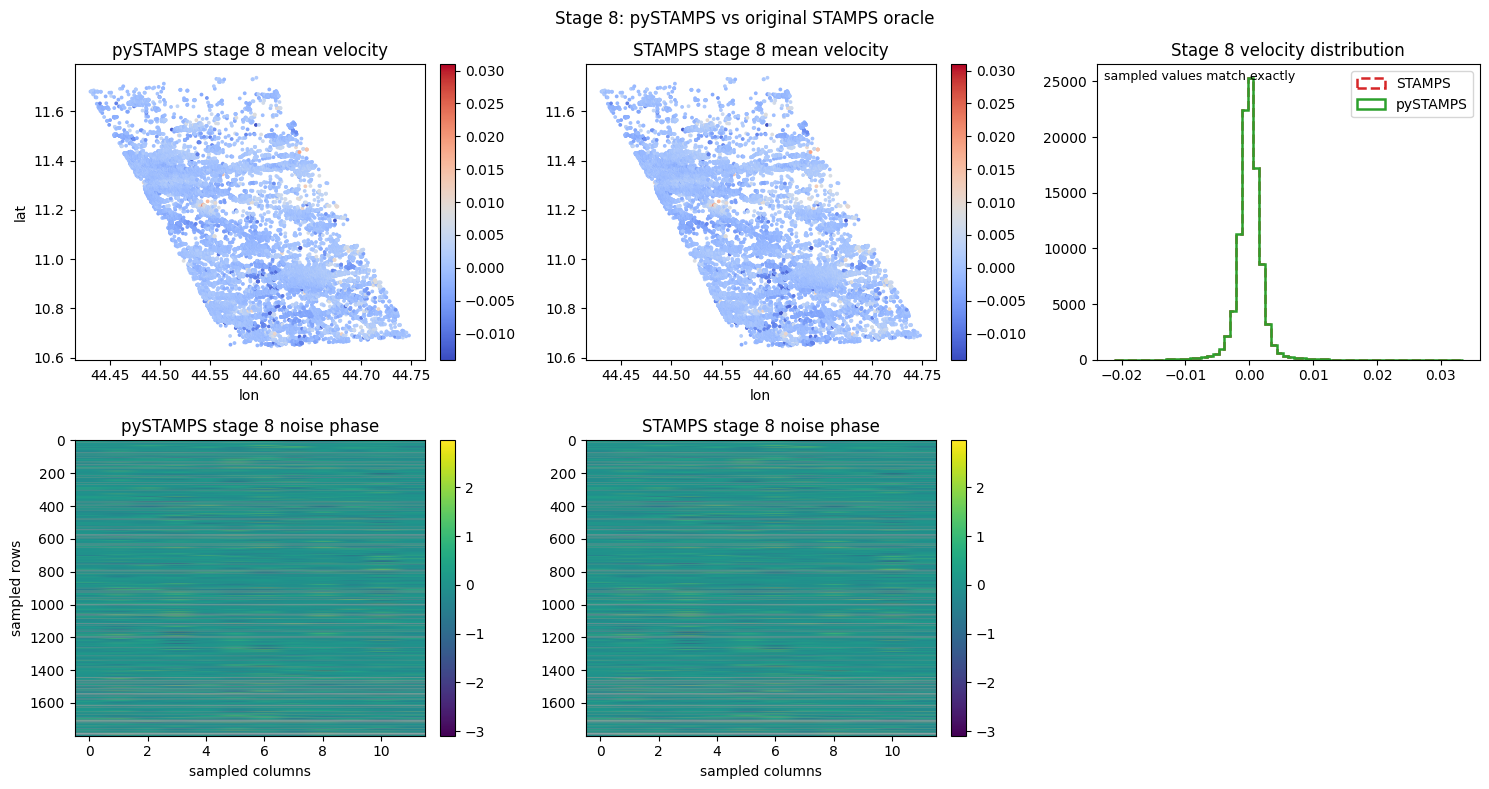

In [10]:
stage_8 = execute_stage(context, 8)
fig = plot_stage_comparison(context, 8)
plt.show()

## Final summary

This cell is intentionally strict: it raises if any stage-scoped comparison is not fully matched.

In [11]:
stage_results = [stage_1, stage_2, stage_3, stage_4, stage_5, stage_6, stage_7, stage_8]
failed_stages = []
print("stage | mode | checked | failed | matched")
for item in stage_results:
    run = item["run"]
    verify = item["verify"]
    if verify["failed"] or not verify["ok"]:
        failed_stages.append(run["stage_id"])
    print(
        f"{run['stage_id']:>5} | {run['execution_mode']} | "
        f"{verify['checked']:>7} | {verify['failed']:>6} | {verify['ok']}"
    )

print(f"scratch dataset: {repo_label(context.scratch_root)}")
if failed_stages:
    raise AssertionError(f"Stage parity failed for: {failed_stages}")
print("OK: stages 1 through 8 all matched")

stage | mode | checked | failed | matched
    1 | latest pySTAMPS outputs |      20 |      0 | True
    2 | STAMPS oracle replay |       4 |      0 | True
    3 | STAMPS oracle replay |       4 |      0 | True
    4 | STAMPS oracle replay |       4 |      0 | True
    5 | STAMPS oracle replay |      41 |      0 | True
    6 | STAMPS oracle replay |       5 |      0 | True
    7 | STAMPS oracle replay |       2 |      0 | True
    8 | STAMPS oracle replay |       2 |      0 | True
scratch dataset: <repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run
OK: stages 1 through 8 all matched
